In [1]:
!pip install pandas numpy matplotlib seaborn scipy statsmodels scikit-learn

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr
from statsmodels.tsa.stattools import grangercausalitytests
import warnings
warnings.filterwarnings('ignore')

# Try to import sklearn, if it fails we'll use alternative implementation
try:
    from sklearn.feature_selection import mutual_info_regression
    sklearn_available = True
except:
    print("Warning: sklearn import failed, will use alternative MI implementation")
    sklearn_available = False

# Load the dataset
df = pd.read_csv('ALL_MERGED.csv')
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst few rows:")
print(df.head())
print("\nDataset info:")
print(df.info())

Dataset shape: (3654, 15)

Column names:
['Date', 'Nickel_Fut', 'Coal_Fut_Newcastle', 'Palm_Oil_Fut', 'USD_IDR', 'CNY_IDR', 'EUR_IDR', 'BTC_USD', 'FTSE100', 'HANGSENG', 'NIKKEI225', 'SNP500', 'DOW30', 'SSE_Composite', 'JKSE']

First few rows:
       Date  Nickel_Fut  Coal_Fut_Newcastle  Palm_Oil_Fut  USD_IDR  CNY_IDR  \
0  5/1/2015     13750.0                62.2          2136  12962.5  2089.78   
1  5/2/2015     13750.0                62.2          2136  12962.5  2089.78   
2  5/3/2015     13750.0                62.2          2136  12962.5  2089.78   
3  5/4/2015     13750.0                62.2          2136  12980.0  2090.51   
4  5/5/2015     14245.0                62.5          2136  13047.5  2102.39   

   EUR_IDR     BTC_USD      FTSE100     HANGSENG    NIKKEI225       SNP500  \
0  14519.9  232.078995  6986.000000  28123.82031  19531.63086  2108.290039   
1  14519.9  234.929993  6986.000000  28123.82031  19531.63086  2108.290039   
2  14519.9  240.358002  6986.000000  28123.82031

In [3]:
# Prepare the data - separate features and target
# Drop Date column and separate JKSE (target) from features
df_clean = df.drop('Date', axis=1)
feature_cols = [col for col in df_clean.columns if col != 'JKSE']
target_col = 'JKSE'

print("Features:", feature_cols)
print("\nTarget:", target_col)
print("\nNumber of features:", len(feature_cols))

# Check for missing values
print("\nMissing values:")
print(df_clean.isnull().sum())

Features: ['Nickel_Fut', 'Coal_Fut_Newcastle', 'Palm_Oil_Fut', 'USD_IDR', 'CNY_IDR', 'EUR_IDR', 'BTC_USD', 'FTSE100', 'HANGSENG', 'NIKKEI225', 'SNP500', 'DOW30', 'SSE_Composite']

Target: JKSE

Number of features: 13

Missing values:
Nickel_Fut            0
Coal_Fut_Newcastle    0
Palm_Oil_Fut          0
USD_IDR               0
CNY_IDR               0
EUR_IDR               0
BTC_USD               0
FTSE100               0
HANGSENG              0
NIKKEI225             0
SNP500                0
DOW30                 0
SSE_Composite         0
JKSE                  0
dtype: int64


In [4]:
# 1. PEARSON CORRELATION
print("="*80)
print("1. PEARSON CORRELATION")
print("="*80)

# Calculate Pearson correlation with JKSE
pearson_corr = df_clean[feature_cols].corrwith(df_clean[target_col])
pearson_corr = pearson_corr.sort_values(ascending=False)

print("\nPearson Correlation with JKSE:")
print(pearson_corr)

# Calculate p-values for Pearson correlation
pearson_pvalues = {}
for feature in feature_cols:
    corr, pval = stats.pearsonr(df_clean[feature], df_clean[target_col])
    pearson_pvalues[feature] = pval

pearson_pvalues_series = pd.Series(pearson_pvalues).sort_values()
print("\nPearson Correlation p-values:")
print(pearson_pvalues_series)

# Create results dataframe
pearson_results = pd.DataFrame({
    'Feature': pearson_corr.index,
    'Correlation': pearson_corr.values,
    'P-value': [pearson_pvalues[feat] for feat in pearson_corr.index]
})
print("\nPearson Correlation Results:")
print(pearson_results)

1. PEARSON CORRELATION

Pearson Correlation with JKSE:
DOW30                 0.836926
FTSE100               0.803004
SNP500                0.793023
NIKKEI225             0.790355
BTC_USD               0.659040
Nickel_Fut            0.627525
Palm_Oil_Fut          0.609392
USD_IDR               0.600870
Coal_Fut_Newcastle    0.590716
EUR_IDR               0.409928
CNY_IDR               0.389140
SSE_Composite        -0.081803
HANGSENG             -0.303693
dtype: float64

Pearson Correlation p-values:
Nickel_Fut             0.000000e+00
Coal_Fut_Newcastle     0.000000e+00
Palm_Oil_Fut           0.000000e+00
USD_IDR                0.000000e+00
FTSE100                0.000000e+00
BTC_USD                0.000000e+00
SNP500                 0.000000e+00
NIKKEI225              0.000000e+00
DOW30                  0.000000e+00
EUR_IDR               4.104312e-148
CNY_IDR               2.060066e-132
HANGSENG               7.965709e-79
SSE_Composite          7.364920e-07
dtype: float64

Pearson Corr

In [5]:
# 2. SPEARMAN CORRELATION
print("\n" + "="*80)
print("2. SPEARMAN CORRELATION")
print("="*80)

# Calculate Spearman correlation with JKSE
spearman_corr = {}
spearman_pvalues = {}

for feature in feature_cols:
    corr, pval = spearmanr(df_clean[feature], df_clean[target_col])
    spearman_corr[feature] = corr
    spearman_pvalues[feature] = pval

spearman_corr_series = pd.Series(spearman_corr).sort_values(ascending=False)
spearman_pvalues_series = pd.Series(spearman_pvalues)

print("\nSpearman Correlation with JKSE:")
print(spearman_corr_series)

print("\nSpearman Correlation p-values:")
print(spearman_pvalues_series[spearman_corr_series.index])

# Create results dataframe
spearman_results = pd.DataFrame({
    'Feature': spearman_corr_series.index,
    'Correlation': spearman_corr_series.values,
    'P-value': [spearman_pvalues[feat] for feat in spearman_corr_series.index]
})
print("\nSpearman Correlation Results:")
print(spearman_results)


2. SPEARMAN CORRELATION

Spearman Correlation with JKSE:
DOW30                 0.836283
SNP500                0.821298
Coal_Fut_Newcastle    0.820764
NIKKEI225             0.817198
BTC_USD               0.786457
Nickel_Fut            0.764300
FTSE100               0.756960
USD_IDR               0.653092
Palm_Oil_Fut          0.614978
CNY_IDR               0.440773
EUR_IDR               0.381969
SSE_Composite        -0.001434
HANGSENG             -0.378571
dtype: float64

Spearman Correlation p-values:
DOW30                  0.000000e+00
SNP500                 0.000000e+00
Coal_Fut_Newcastle     0.000000e+00
NIKKEI225              0.000000e+00
BTC_USD                0.000000e+00
Nickel_Fut             0.000000e+00
FTSE100                0.000000e+00
USD_IDR                0.000000e+00
Palm_Oil_Fut           0.000000e+00
CNY_IDR               1.470423e-173
EUR_IDR               2.968605e-127
SSE_Composite          9.309308e-01
HANGSENG              7.454626e-125
dtype: float64

Spearman

In [6]:
# 3. DISTANCE CORRELATION (dCor)
print("\n" + "="*80)
print("3. DISTANCE CORRELATION (dCor)")
print("="*80)

def distance_correlation(x, y):
    """Calculate distance correlation between two variables"""
    n = len(x)
    
    # Center the distance matrices
    def center_distance_matrix(D):
        row_mean = D.mean(axis=1, keepdims=True)
        col_mean = D.mean(axis=0, keepdims=True)
        grand_mean = D.mean()
        return D - row_mean - col_mean + grand_mean
    
    # Calculate pairwise distances
    x = x.reshape(-1, 1) if x.ndim == 1 else x
    y = y.reshape(-1, 1) if y.ndim == 1 else y
    
    dx = squareform(pdist(x, metric='euclidean'))
    dy = squareform(pdist(y, metric='euclidean'))
    
    # Center the distance matrices
    dx_centered = center_distance_matrix(dx)
    dy_centered = center_distance_matrix(dy)
    
    # Calculate dCov and dVar
    dcov_xy = np.sqrt(np.mean(dx_centered * dy_centered))
    dvar_x = np.sqrt(np.mean(dx_centered * dx_centered))
    dvar_y = np.sqrt(np.mean(dy_centered * dy_centered))
    
    # Calculate dCor
    if dvar_x > 0 and dvar_y > 0:
        dcor = dcov_xy / np.sqrt(dvar_x * dvar_y)
    else:
        dcor = 0
    
    return dcor

# Calculate distance correlation for each feature
dcor_results = {}
for feature in feature_cols:
    x = df_clean[feature].values
    y = df_clean[target_col].values
    dcor = distance_correlation(x, y)
    dcor_results[feature] = dcor

dcor_series = pd.Series(dcor_results).sort_values(ascending=False)
print("\nDistance Correlation with JKSE:")
print(dcor_series)

# Create results dataframe
dcor_df = pd.DataFrame({
    'Feature': dcor_series.index,
    'dCor': dcor_series.values
})
print("\nDistance Correlation Results:")
print(dcor_df)


3. DISTANCE CORRELATION (dCor)

Distance Correlation with JKSE:
DOW30                 0.817482
SNP500                0.779975
NIKKEI225             0.779011
FTSE100               0.777043
Nickel_Fut            0.727661
BTC_USD               0.690276
Coal_Fut_Newcastle    0.690002
Palm_Oil_Fut          0.668707
USD_IDR               0.645572
HANGSENG              0.566192
CNY_IDR               0.462381
EUR_IDR               0.452372
SSE_Composite         0.183428
dtype: float64

Distance Correlation Results:
               Feature      dCor
0                DOW30  0.817482
1               SNP500  0.779975
2            NIKKEI225  0.779011
3              FTSE100  0.777043
4           Nickel_Fut  0.727661
5              BTC_USD  0.690276
6   Coal_Fut_Newcastle  0.690002
7         Palm_Oil_Fut  0.668707
8              USD_IDR  0.645572
9             HANGSENG  0.566192
10             CNY_IDR  0.462381
11             EUR_IDR  0.452372
12       SSE_Composite  0.183428


In [7]:
# 4. MUTUAL INFORMATION
print("\n" + "="*80)
print("4. MUTUAL INFORMATION")
print("="*80)

# First try sklearn
try:
    print("Attempting to use sklearn's mutual_info_regression...")
    from sklearn.feature_selection import mutual_info_regression
    X = df_clean[feature_cols].values
    y = df_clean[target_col].values
    mi_scores = mutual_info_regression(X, y, random_state=42)
    mi_results = pd.Series(mi_scores, index=feature_cols).sort_values(ascending=False)
    print("✓ sklearn mutual_info_regression succeeded!")
except Exception as e:
    print(f"✗ sklearn failed: {str(e)}")
    print("Using alternative histogram-based MI implementation...")
    
    def calc_mi_manual(x, y, bins=50):
        """Calculate mutual information using histogram-based method"""
        c_xy = np.histogram2d(x, y, bins)[0]
        c_x = np.histogram(x, bins)[0]
        c_y = np.histogram(y, bins)[0]
        
        # Add small value to avoid log(0)
        c_xy = c_xy + 1e-10
        c_x = c_x + 1e-10
        c_y = c_y + 1e-10
        
        # Normalize
        p_xy = c_xy / np.sum(c_xy)
        p_x = c_x / np.sum(c_x)
        p_y = c_y / np.sum(c_y)
        
        # Calculate MI
        p_x_y = p_x[:, None] * p_y[None, :]
        nzs = p_xy > 0
        
        mi = np.sum(p_xy[nzs] * np.log(p_xy[nzs] / p_x_y[nzs]))
        return mi
    
    mi_scores = {}
    for feature in feature_cols:
        x = df_clean[feature].values
        y = df_clean[target_col].values
        mi = calc_mi_manual(x, y)
        mi_scores[feature] = mi
    mi_results = pd.Series(mi_scores).sort_values(ascending=False)

print("\nMutual Information with JKSE:")
print(mi_results)

# Create results dataframe
mi_df = pd.DataFrame({
    'Feature': mi_results.index,
    'MI_Score': mi_results.values
})
print("\nMutual Information Results:")
print(mi_df)


4. MUTUAL INFORMATION
Attempting to use sklearn's mutual_info_regression...
✓ sklearn mutual_info_regression succeeded!

Mutual Information with JKSE:
SNP500                2.239805
Coal_Fut_Newcastle    2.178256
DOW30                 2.120650
USD_IDR               1.999483
NIKKEI225             1.877045
Nickel_Fut            1.857577
HANGSENG              1.847220
Palm_Oil_Fut          1.810717
BTC_USD               1.777153
FTSE100               1.621038
CNY_IDR               1.484452
EUR_IDR               1.333334
SSE_Composite         1.263001
dtype: float64

Mutual Information Results:
               Feature  MI_Score
0               SNP500  2.239805
1   Coal_Fut_Newcastle  2.178256
2                DOW30  2.120650
3              USD_IDR  1.999483
4            NIKKEI225  1.877045
5           Nickel_Fut  1.857577
6             HANGSENG  1.847220
7         Palm_Oil_Fut  1.810717
8              BTC_USD  1.777153
9              FTSE100  1.621038
10             CNY_IDR  1.484452
11   

In [8]:
# 5. GRANGER CAUSALITY TEST
print("\n" + "="*80)
print("5. GRANGER CAUSALITY TEST")
print("="*80)
print("Testing whether each feature Granger-causes JKSE")
print("(This may take a while...)\n")

# Granger causality requires stationary data and tests at different lags
max_lag = 5  # Test up to 5 lags
granger_results = {}

for feature in feature_cols:
    print(f"\nTesting {feature} -> JKSE")
    try:
        # Create dataframe with feature and target
        test_data = df_clean[[feature, target_col]].dropna()
        
        # Perform Granger causality test
        gc_result = grangercausalitytests(test_data, maxlag=max_lag, verbose=False)
        
        # Extract p-values for each lag
        p_values = []
        for lag in range(1, max_lag + 1):
            # Use F-test p-value
            p_val = gc_result[lag][0]['ssr_ftest'][1]
            p_values.append(p_val)
        
        # Store minimum p-value (strongest evidence) and corresponding lag
        min_pval = min(p_values)
        best_lag = p_values.index(min_pval) + 1
        
        granger_results[feature] = {
            'min_pvalue': min_pval,
            'best_lag': best_lag,
            'all_pvalues': p_values
        }
        
        print(f"  Best lag: {best_lag}, p-value: {min_pval:.6f}")
        
    except Exception as e:
        print(f"  Error: {str(e)}")
        granger_results[feature] = {
            'min_pvalue': np.nan,
            'best_lag': np.nan,
            'all_pvalues': [np.nan] * max_lag
        }

# Create results dataframe
granger_df = pd.DataFrame({
    'Feature': list(granger_results.keys()),
    'Min_P_value': [granger_results[f]['min_pvalue'] for f in granger_results],
    'Best_Lag': [granger_results[f]['best_lag'] for f in granger_results],
    'Significant_at_5%': [granger_results[f]['min_pvalue'] < 0.05 for f in granger_results]
}).sort_values('Min_P_value')

print("\n" + "="*80)
print("Granger Causality Test Results Summary:")
print("="*80)
print(granger_df)
print(f"\nNumber of features that Granger-cause JKSE (p < 0.05): {granger_df['Significant_at_5%'].sum()}")


5. GRANGER CAUSALITY TEST
Testing whether each feature Granger-causes JKSE
(This may take a while...)


Testing Nickel_Fut -> JKSE
  Best lag: 1, p-value: 0.002473

Testing Coal_Fut_Newcastle -> JKSE
  Best lag: 1, p-value: 0.481073

Testing Palm_Oil_Fut -> JKSE
  Best lag: 4, p-value: 0.007088

Testing USD_IDR -> JKSE
  Best lag: 4, p-value: 0.000029

Testing CNY_IDR -> JKSE
  Best lag: 2, p-value: 0.000360

Testing EUR_IDR -> JKSE
  Best lag: 5, p-value: 0.000038

Testing BTC_USD -> JKSE
  Best lag: 3, p-value: 0.159386

Testing FTSE100 -> JKSE
  Best lag: 5, p-value: 0.000651

Testing HANGSENG -> JKSE
  Best lag: 2, p-value: 0.486583

Testing NIKKEI225 -> JKSE
  Best lag: 4, p-value: 0.000576

Testing SNP500 -> JKSE
  Best lag: 3, p-value: 0.000304

Testing DOW30 -> JKSE
  Best lag: 5, p-value: 0.000211

Testing SSE_Composite -> JKSE
  Best lag: 5, p-value: 0.327653

Granger Causality Test Results Summary:
               Feature  Min_P_value  Best_Lag  Significant_at_5%
3          

In [9]:
def transfer_entropy(source, target, lag=1, bins=10):
    """
    Calculate Transfer Entropy from source to target
    """
    # Ensure input is numpy array
    source = np.asarray(source)
    target = np.asarray(target)
    
    # 1. Handle NaNs in raw data
    valid_mask = ~(np.isnan(source) | np.isnan(target))
    source = source[valid_mask]
    target = target[valid_mask]
    
    if len(source) < lag + 1:
        return np.nan
    
    # 2. Discretize data into bins
    source_binned = pd.cut(source, bins=bins, labels=False, duplicates='drop')
    target_binned = pd.cut(target, bins=bins, labels=False, duplicates='drop')
    
    # 3. FIX: Use pd.isna() instead of .isna()
    # This works regardless of whether pd.cut returns a Series, Categorical, or Array
    valid_idx = ~(pd.isna(source_binned) | pd.isna(target_binned))
    
    # Filter and force to integer numpy arrays
    # We cast to np.array first to ensure indexing works
    source_binned = np.array(source_binned)[valid_idx].astype(int)
    target_binned = np.array(target_binned)[valid_idx].astype(int)
    
    if len(source_binned) < lag + 1:
        return np.nan
    
    # Create lagged versions
    Y_t = target_binned[lag:]
    Y_past = target_binned[:-lag]
    X_past = source_binned[:-lag]
    
    # Calculate joint probabilities
    def prob_joint(*arrays):
        combined = np.column_stack(arrays)
        unique_rows = np.unique(combined, axis=0)
        probs = {}
        for row in unique_rows:
            # Efficiently count matches
            count = np.sum(np.all(combined == row, axis=1))
            key = tuple(row)
            probs[key] = count / len(combined)
        return probs
    
    # H(Y_t | Y_t-1): Conditional entropy without source
    p_yt_ypast = prob_joint(Y_t, Y_past)
    p_ypast = prob_joint(Y_past)
    
    h_yt_given_ypast = 0
    for (yt, ypast), p in p_yt_ypast.items():
        if p > 0:
            p_yt_cond = p / p_ypast.get((ypast,), 1e-10)
            h_yt_given_ypast -= p * np.log2(p_yt_cond + 1e-10)
    
    # H(Y_t | Y_t-1, X_t-lag): Conditional entropy with source
    p_yt_ypast_xpast = prob_joint(Y_t, Y_past, X_past)
    p_ypast_xpast = prob_joint(Y_past, X_past)
    
    h_yt_given_ypast_xpast = 0
    for (yt, ypast, xpast), p in p_yt_ypast_xpast.items():
        if p > 0:
            p_yt_cond = p / p_ypast_xpast.get((ypast, xpast), 1e-10)
            h_yt_given_ypast_xpast -= p * np.log2(p_yt_cond + 1e-10)
    
    # Transfer Entropy
    te = h_yt_given_ypast - h_yt_given_ypast_xpast
    
    return max(0, te)

# --- Your Execution Code Below ---
# (You can run your loop exactly as before with this fixed function)

# Calculate Transfer Entropy for each feature
te_results = {}
lag_value = 1
bins_value = 10

for feature in feature_cols:
    print(f"Analyzing {feature} -> JKSE")
    try:
        x = df_clean[feature].values
        y = df_clean[target_col].values
        te = transfer_entropy(x, y, lag=lag_value, bins=bins_value)
        te_results[feature] = te
        print(f"  Transfer Entropy: {te:.6f}")
    except Exception as e:
        print(f"  Error: {str(e)}")
        te_results[feature] = np.nan

te_series = pd.Series(te_results).sort_values(ascending=False)
print("\nTransfer Entropy Results (Feature -> JKSE):")
print(te_series)

# Create results dataframe
te_df = pd.DataFrame({
    'Feature': te_series.index,
    'TE_Score': te_series.values
})
print("\nTransfer Entropy Results DataFrame:")
print(te_df)

print("\n" + "="*80)
print("Transfer Entropy Analysis Complete")
print("="*80)
print(f"Mean TE: {te_series.mean():.6f}")
print(f"Max TE: {te_series.max():.6f}")
print(f"Min TE: {te_series.min():.6f}")


Analyzing Nickel_Fut -> JKSE
  Transfer Entropy: 0.019287
Analyzing Coal_Fut_Newcastle -> JKSE
  Transfer Entropy: 0.023914
Analyzing Palm_Oil_Fut -> JKSE
  Transfer Entropy: 0.030084
Analyzing USD_IDR -> JKSE
  Transfer Entropy: 0.047937
Analyzing CNY_IDR -> JKSE
  Transfer Entropy: 0.051935
Analyzing EUR_IDR -> JKSE
  Transfer Entropy: 0.038437
Analyzing BTC_USD -> JKSE
  Transfer Entropy: 0.030818
Analyzing FTSE100 -> JKSE
  Transfer Entropy: 0.028995
Analyzing HANGSENG -> JKSE
  Transfer Entropy: 0.035173
Analyzing NIKKEI225 -> JKSE
  Transfer Entropy: 0.035530
Analyzing SNP500 -> JKSE
  Transfer Entropy: 0.035318
Analyzing DOW30 -> JKSE
  Transfer Entropy: 0.039406
Analyzing SSE_Composite -> JKSE
  Transfer Entropy: 0.027195

Transfer Entropy Results (Feature -> JKSE):
CNY_IDR               0.051935
USD_IDR               0.047937
DOW30                 0.039406
EUR_IDR               0.038437
NIKKEI225             0.035530
SNP500                0.035318
HANGSENG              0.03517

In [10]:
# CONSOLIDATE ALL RESULTS
print("\n" + "="*80)
print("CONSOLIDATED RESULTS SUMMARY")
print("="*80)

# Create a comprehensive results dataframe
all_results = pd.DataFrame({
    'Feature': feature_cols
})

# Add Pearson correlation
all_results = all_results.merge(
    pearson_results[['Feature', 'Correlation', 'P-value']].rename(
        columns={'Correlation': 'Pearson_Corr', 'P-value': 'Pearson_Pval'}
    ), on='Feature'
)

# Add Spearman correlation
all_results = all_results.merge(
    spearman_results[['Feature', 'Correlation', 'P-value']].rename(
        columns={'Correlation': 'Spearman_Corr', 'P-value': 'Spearman_Pval'}
    ), on='Feature'
)

# Add Distance Correlation
all_results = all_results.merge(dcor_df, on='Feature')

# Add Mutual Information
all_results = all_results.merge(mi_df, on='Feature')

# Add Granger Causality
all_results = all_results.merge(
    granger_df[['Feature', 'Min_P_value', 'Best_Lag']].rename(
        columns={'Min_P_value': 'Granger_Pval', 'Best_Lag': 'Granger_Lag'}
    ), on='Feature'
)

# Add Transfer Entropy
all_results = all_results.merge(te_df, on='Feature')

# Sort by absolute Pearson correlation
all_results['Abs_Pearson'] = all_results['Pearson_Corr'].abs()
all_results = all_results.sort_values('Abs_Pearson', ascending=False)
all_results = all_results.drop('Abs_Pearson', axis=1)

print("\nComprehensive Results Table:")
print(all_results.to_string(index=False))

# Save to CSV
all_results.to_csv('Feature_Analysis_Results.csv', index=False)
print("\nResults saved to 'Feature_Analysis_Results.csv'")


CONSOLIDATED RESULTS SUMMARY

Comprehensive Results Table:
           Feature  Pearson_Corr  Pearson_Pval  Spearman_Corr  Spearman_Pval     dCor  MI_Score  Granger_Pval  Granger_Lag  TE_Score
             DOW30      0.836926  0.000000e+00       0.836283   0.000000e+00 0.817482  2.120650      0.000211            5  0.039406
           FTSE100      0.803004  0.000000e+00       0.756960   0.000000e+00 0.777043  1.621038      0.000651            5  0.028995
            SNP500      0.793023  0.000000e+00       0.821298   0.000000e+00 0.779975  2.239805      0.000304            3  0.035318
         NIKKEI225      0.790355  0.000000e+00       0.817198   0.000000e+00 0.779011  1.877045      0.000576            4  0.035530
           BTC_USD      0.659040  0.000000e+00       0.786457   0.000000e+00 0.690276  1.777153      0.159386            3  0.030818
        Nickel_Fut      0.627525  0.000000e+00       0.764300   0.000000e+00 0.727661  1.857577      0.002473            1  0.019287
      Pal


VISUALIZATION 1: Correlation Methods

Visualization 1 saved as 'Feature_Analysis_Correlations.png'


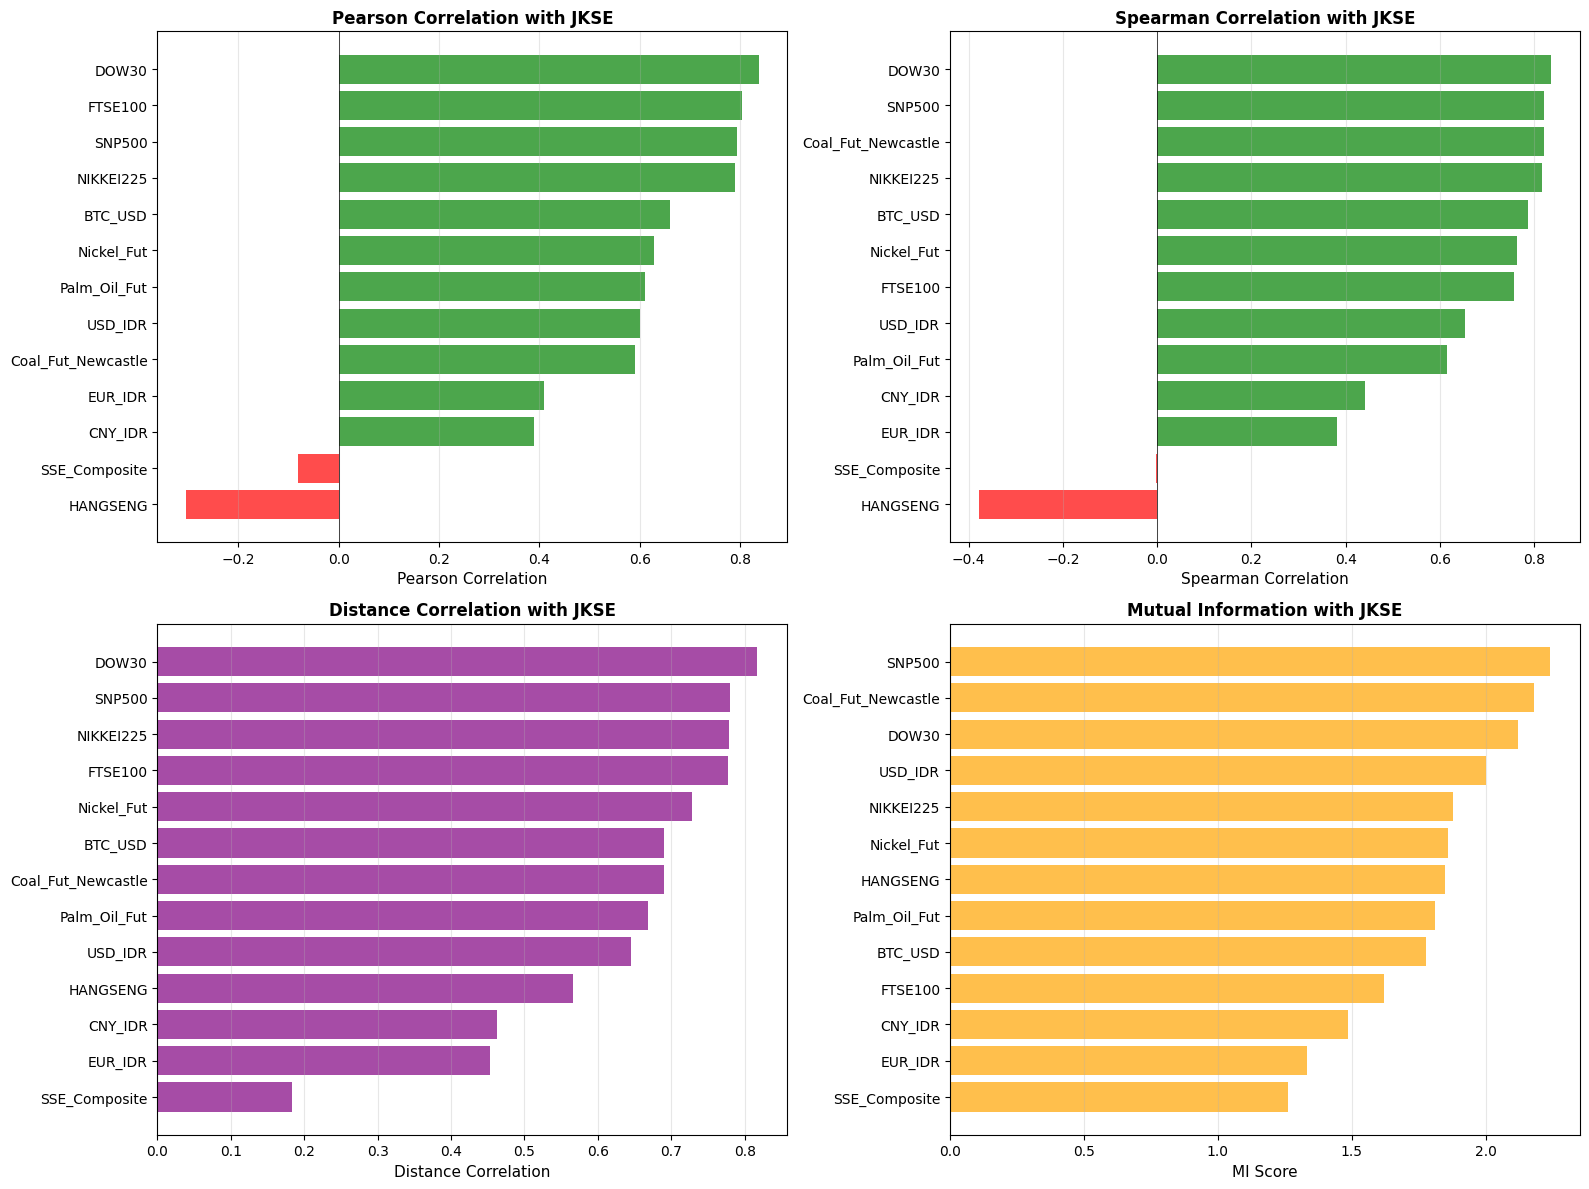

In [11]:
# VISUALIZATION 1: Pearson, Spearman, Distance Correlation & MI
print("\n" + "="*80)
print("VISUALIZATION 1: Correlation Methods")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Pearson Correlation Bar Plot
ax1 = axes[0, 0]
pearson_plot_data = all_results.sort_values('Pearson_Corr', ascending=True)
colors = ['red' if x < 0 else 'green' for x in pearson_plot_data['Pearson_Corr']]
ax1.barh(pearson_plot_data['Feature'], pearson_plot_data['Pearson_Corr'], color=colors, alpha=0.7)
ax1.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax1.set_xlabel('Pearson Correlation', fontsize=11)
ax1.set_title('Pearson Correlation with JKSE', fontsize=12, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# 2. Spearman Correlation Bar Plot
ax2 = axes[0, 1]
spearman_plot_data = all_results.sort_values('Spearman_Corr', ascending=True)
colors = ['red' if x < 0 else 'green' for x in spearman_plot_data['Spearman_Corr']]
ax2.barh(spearman_plot_data['Feature'], spearman_plot_data['Spearman_Corr'], color=colors, alpha=0.7)
ax2.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax2.set_xlabel('Spearman Correlation', fontsize=11)
ax2.set_title('Spearman Correlation with JKSE', fontsize=12, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

# 3. Distance Correlation Bar Plot
ax3 = axes[1, 0]
dcor_plot_data = all_results.sort_values('dCor', ascending=True)
ax3.barh(dcor_plot_data['Feature'], dcor_plot_data['dCor'], color='purple', alpha=0.7)
ax3.set_xlabel('Distance Correlation', fontsize=11)
ax3.set_title('Distance Correlation with JKSE', fontsize=12, fontweight='bold')
ax3.grid(axis='x', alpha=0.3)

# 4. Mutual Information Bar Plot
ax4 = axes[1, 1]
mi_plot_data = all_results.sort_values('MI_Score', ascending=True)
ax4.barh(mi_plot_data['Feature'], mi_plot_data['MI_Score'], color='orange', alpha=0.7)
ax4.set_xlabel('MI Score', fontsize=11)
ax4.set_title('Mutual Information with JKSE', fontsize=12, fontweight='bold')
ax4.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('Feature_Analysis_Correlations.png', dpi=300, bbox_inches='tight')
print("\nVisualization 1 saved as 'Feature_Analysis_Correlations.png'")
plt.show()

In [12]:
# VISUALIZATION 4: Summary Statistics (Table Format)
print("\n" + "="*80)
print("VISUALIZATION 4: Summary Statistics (Table Format)")
print("="*80)

# Create summary statistics as a structured table
summary_data = {
    'Metric': [
        'Total Features Analyzed',
        'Dataset Size',
        'Pearson Mean |r|',
        'Pearson Max |r|',
        'Pearson Min |r|',
        'Pearson Significant (p<0.05)',
        'Spearman Mean |ρ|',
        'Spearman Max |ρ|',
        'Spearman Min |ρ|',
        'Spearman Significant (p<0.05)',
        'dCor Mean',
        'dCor Max',
        'dCor Min',
        'MI Mean Score',
        'MI Max Score',
        'MI Min Score',
        'Granger Causality (p<0.05)',
        'Granger Best p-value',
        'Granger Worst p-value',
        'Transfer Entropy Mean',
        'Transfer Entropy Max',
        'Transfer Entropy Min'
    ],
    'Value': [
        str(len(all_results)),
        str(len(df_clean)) + ' observations',
        f"{all_results['Pearson_Corr'].abs().mean():.4f}",
        f"{all_results['Pearson_Corr'].abs().max():.4f}",
        f"{all_results['Pearson_Corr'].abs().min():.4f}",
        f"{(all_results['Pearson_Pval'] < 0.05).sum()} / {len(all_results)}",
        f"{all_results['Spearman_Corr'].abs().mean():.4f}",
        f"{all_results['Spearman_Corr'].abs().max():.4f}",
        f"{all_results['Spearman_Corr'].abs().min():.4f}",
        f"{(all_results['Spearman_Pval'] < 0.05).sum()} / {len(all_results)}",
        f"{all_results['dCor'].mean():.4f}",
        f"{all_results['dCor'].max():.4f}",
        f"{all_results['dCor'].min():.4f}",
        f"{all_results['MI_Score'].mean():.4f}",
        f"{all_results['MI_Score'].max():.4f}",
        f"{all_results['MI_Score'].min():.4f}",
        f"{(all_results['Granger_Pval'] < 0.05).sum()} / {len(all_results)}",
        f"{all_results['Granger_Pval'].min():.6f}",
        f"{all_results['Granger_Pval'].max():.6f}",
        f"{all_results['TE_Score'].mean():.6f}",
        f"{all_results['TE_Score'].max():.6f}",
        f"{all_results['TE_Score'].min():.6f}"
    ]
}

summary_df = pd.DataFrame(summary_data)

# Display as a pandas table directly
print("\n")
print(summary_df.to_string(index=False))
print("\n")

# Save to CSV as well
summary_df.to_csv('Summary_Statistics.csv', index=False)
print("Summary Statistics saved to 'Summary_Statistics.csv'")


VISUALIZATION 4: Summary Statistics (Table Format)


                       Metric             Value
      Total Features Analyzed                13
                 Dataset Size 3654 observations
             Pearson Mean |r|            0.5766
              Pearson Max |r|            0.8369
              Pearson Min |r|            0.0818
 Pearson Significant (p<0.05)           13 / 13
            Spearman Mean |ρ|            0.6211
             Spearman Max |ρ|            0.8363
             Spearman Min |ρ|            0.0014
Spearman Significant (p<0.05)           12 / 13
                    dCor Mean            0.6339
                     dCor Max            0.8175
                     dCor Min            0.1834
                MI Mean Score            1.8007
                 MI Max Score            2.2398
                 MI Min Score            1.2630
   Granger Causality (p<0.05)            9 / 13
         Granger Best p-value          0.000029
        Granger Worst p-value     


VISUALIZATION 3: Statistical Significance & Relationships

Visualization 3 saved as 'Feature_Analysis_SignificanceAndRelationships.png'


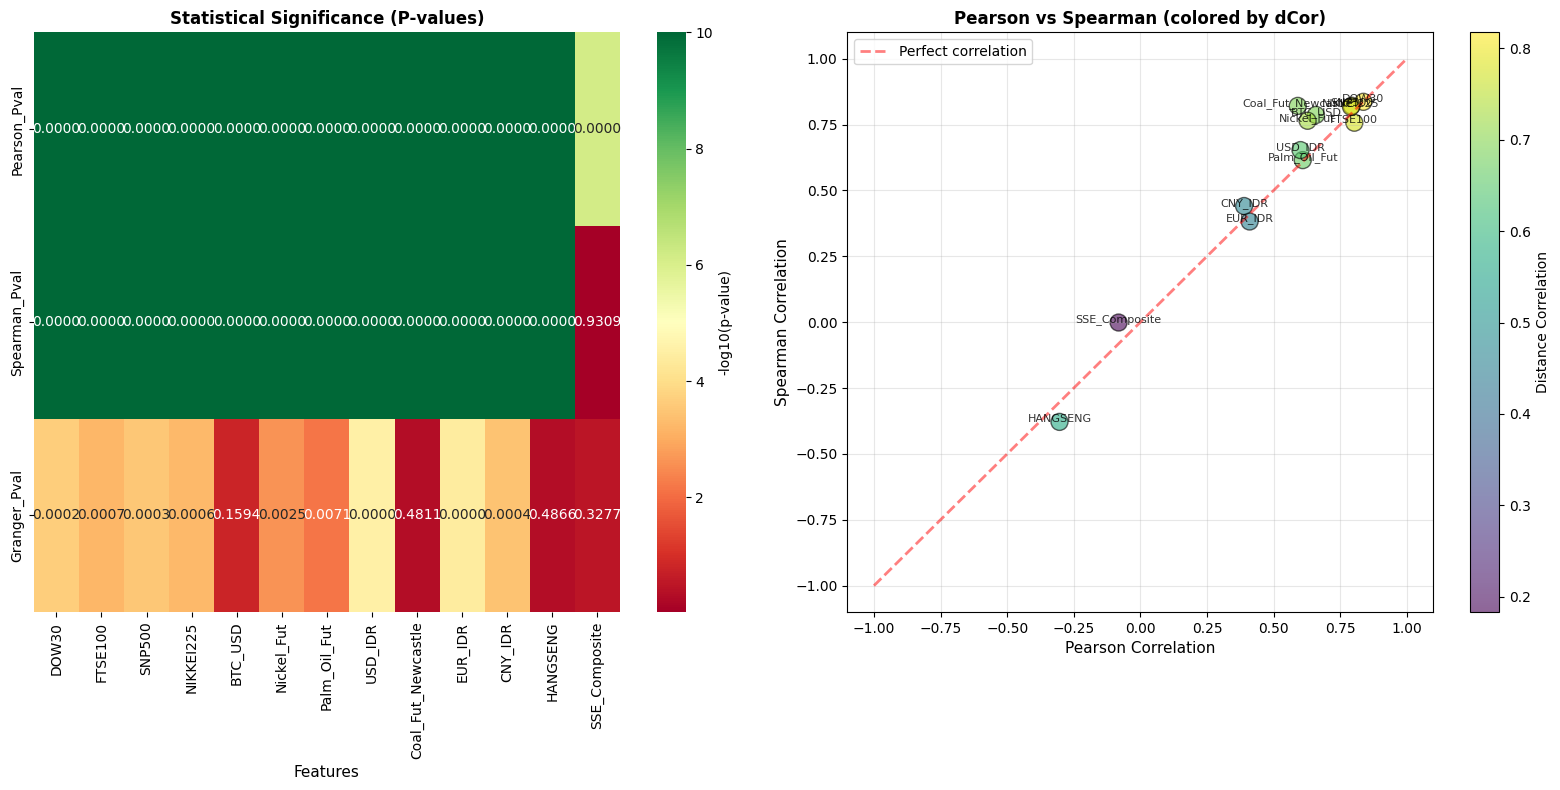

In [13]:
# VISUALIZATION 3: Statistical Significance & Scatter Plot
print("\n" + "="*80)
print("VISUALIZATION 3: Statistical Significance & Relationships")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# 1. Heatmap of P-values
ax7 = axes[0]
pval_data = all_results[['Feature', 'Pearson_Pval', 'Spearman_Pval', 'Granger_Pval']].set_index('Feature')
pval_data_log = -np.log10(pval_data.clip(lower=1e-10))
sns.heatmap(pval_data_log.T, annot=pval_data.T, fmt='.4f', cmap='RdYlGn', 
            cbar_kws={'label': '-log10(p-value)'}, ax=ax7)
ax7.set_title('Statistical Significance (P-values)', fontsize=12, fontweight='bold')
ax7.set_xlabel('Features', fontsize=11)

# 2. Scatter: Pearson vs Spearman (colored by dCor)
ax8 = axes[1]
scatter = ax8.scatter(all_results['Pearson_Corr'], all_results['Spearman_Corr'], 
                      s=150, alpha=0.6, c=all_results['dCor'], cmap='viridis', edgecolors='black', linewidth=1)
for idx, row in all_results.iterrows():
    ax8.annotate(row['Feature'], (row['Pearson_Corr'], row['Spearman_Corr']), 
                fontsize=8, alpha=0.8, ha='center')
ax8.plot([-1, 1], [-1, 1], 'r--', alpha=0.5, linewidth=2, label='Perfect correlation')
ax8.set_xlabel('Pearson Correlation', fontsize=11)
ax8.set_ylabel('Spearman Correlation', fontsize=11)
ax8.set_title('Pearson vs Spearman (colored by dCor)', fontsize=12, fontweight='bold')
ax8.legend(fontsize=10)
ax8.grid(alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax8)
cbar.set_label('Distance Correlation', fontsize=10)

plt.tight_layout()
plt.savefig('Feature_Analysis_SignificanceAndRelationships.png', dpi=300, bbox_inches='tight')
print("\nVisualization 3 saved as 'Feature_Analysis_SignificanceAndRelationships.png'")
plt.show()


VISUALIZATION 3A: P-value Heatmap

Visualization 3A saved as 'Feature_Analysis_PvalueHeatmap.png'


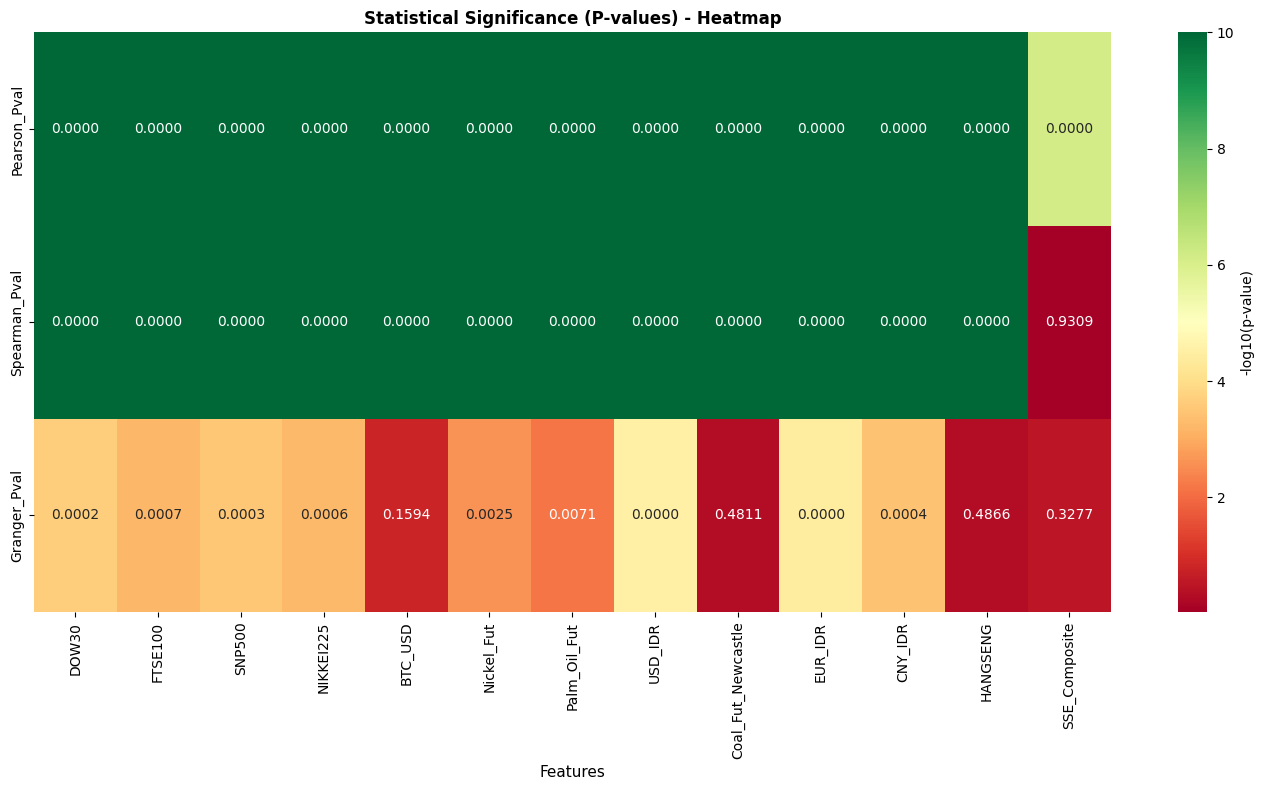

In [14]:
# VISUALIZATION 3A: P-value Heatmap
print("\n" + "="*80)
print("VISUALIZATION 3A: P-value Heatmap")
print("="*80)

fig, ax = plt.subplots(figsize=(14, 8))

pval_data = all_results[['Feature', 'Pearson_Pval', 'Spearman_Pval', 'Granger_Pval']].set_index('Feature')
pval_data_log = -np.log10(pval_data.clip(lower=1e-10))
sns.heatmap(pval_data_log.T, annot=pval_data.T, fmt='.4f', cmap='RdYlGn', 
            cbar_kws={'label': '-log10(p-value)'}, ax=ax)
ax.set_title('Statistical Significance (P-values) - Heatmap', fontsize=12, fontweight='bold')
ax.set_xlabel('Features', fontsize=11)

plt.tight_layout()
plt.savefig('Feature_Analysis_PvalueHeatmap.png', dpi=300, bbox_inches='tight')
print("\nVisualization 3A saved as 'Feature_Analysis_PvalueHeatmap.png'")
plt.show()



VISUALIZATION 3B: Pearson vs Spearman Scatter Plot

Visualization 3B saved as 'Feature_Analysis_PearsonVsSpearman.png'


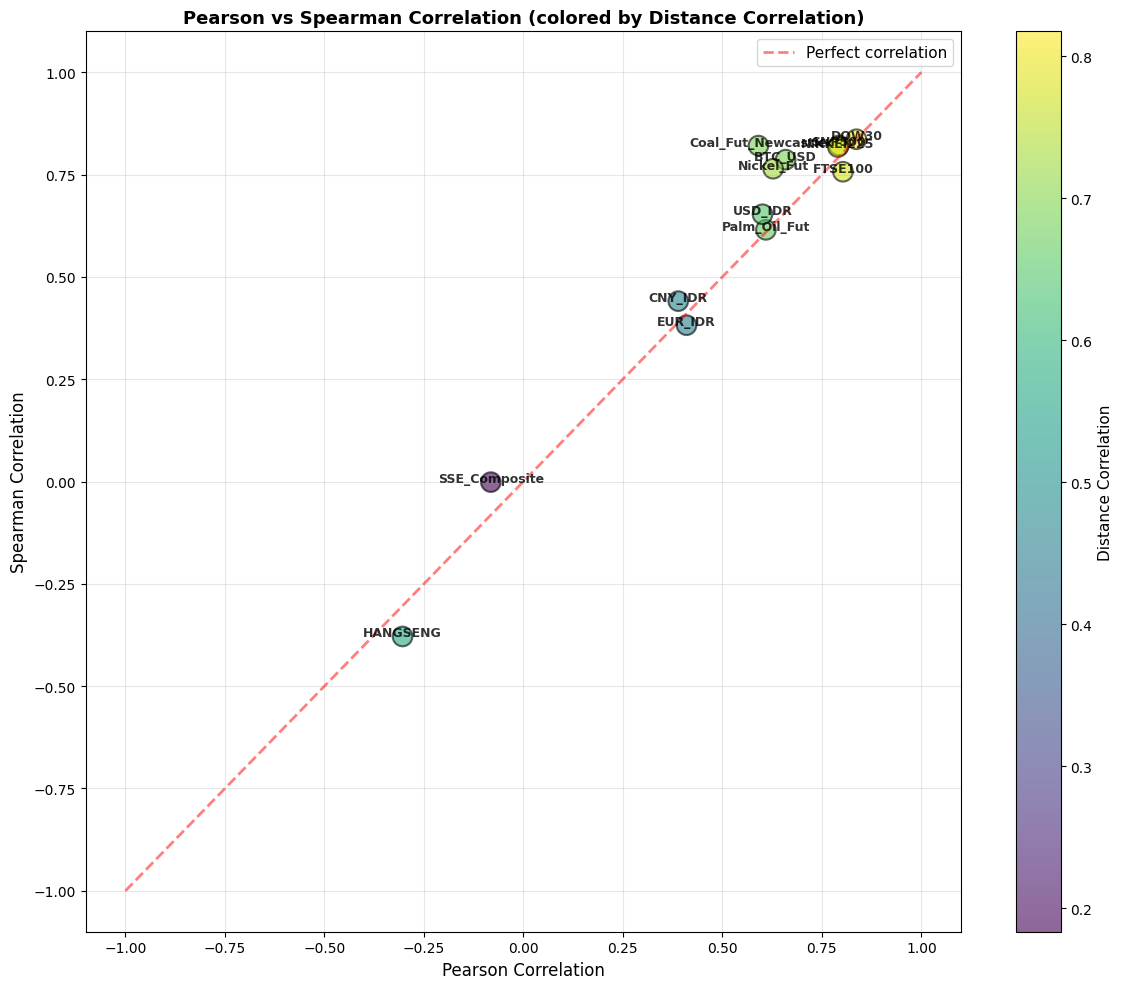

In [15]:
# VISUALIZATION 3B: Pearson vs Spearman Scatter Plot
print("\n" + "="*80)
print("VISUALIZATION 3B: Pearson vs Spearman Scatter Plot")
print("="*80)

fig, ax = plt.subplots(figsize=(12, 10))

scatter = ax.scatter(all_results['Pearson_Corr'], all_results['Spearman_Corr'], 
                      s=200, alpha=0.6, c=all_results['dCor'], cmap='viridis', edgecolors='black', linewidth=1.5)
for idx, row in all_results.iterrows():
    ax.annotate(row['Feature'], (row['Pearson_Corr'], row['Spearman_Corr']), 
                fontsize=9, alpha=0.8, ha='center', fontweight='bold')
ax.plot([-1, 1], [-1, 1], 'r--', alpha=0.5, linewidth=2, label='Perfect correlation')
ax.set_xlabel('Pearson Correlation', fontsize=12)
ax.set_ylabel('Spearman Correlation', fontsize=12)
ax.set_title('Pearson vs Spearman Correlation (colored by Distance Correlation)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Distance Correlation', fontsize=11)

plt.tight_layout()
plt.savefig('Feature_Analysis_PearsonVsSpearman.png', dpi=300, bbox_inches='tight')
print("\nVisualization 3B saved as 'Feature_Analysis_PearsonVsSpearman.png'")
plt.show()



VISUALIZATION 5: Transfer Entropy Analysis (Non-parametric Causality)

Visualization 5 saved as 'Feature_Analysis_TransferEntropy.png'


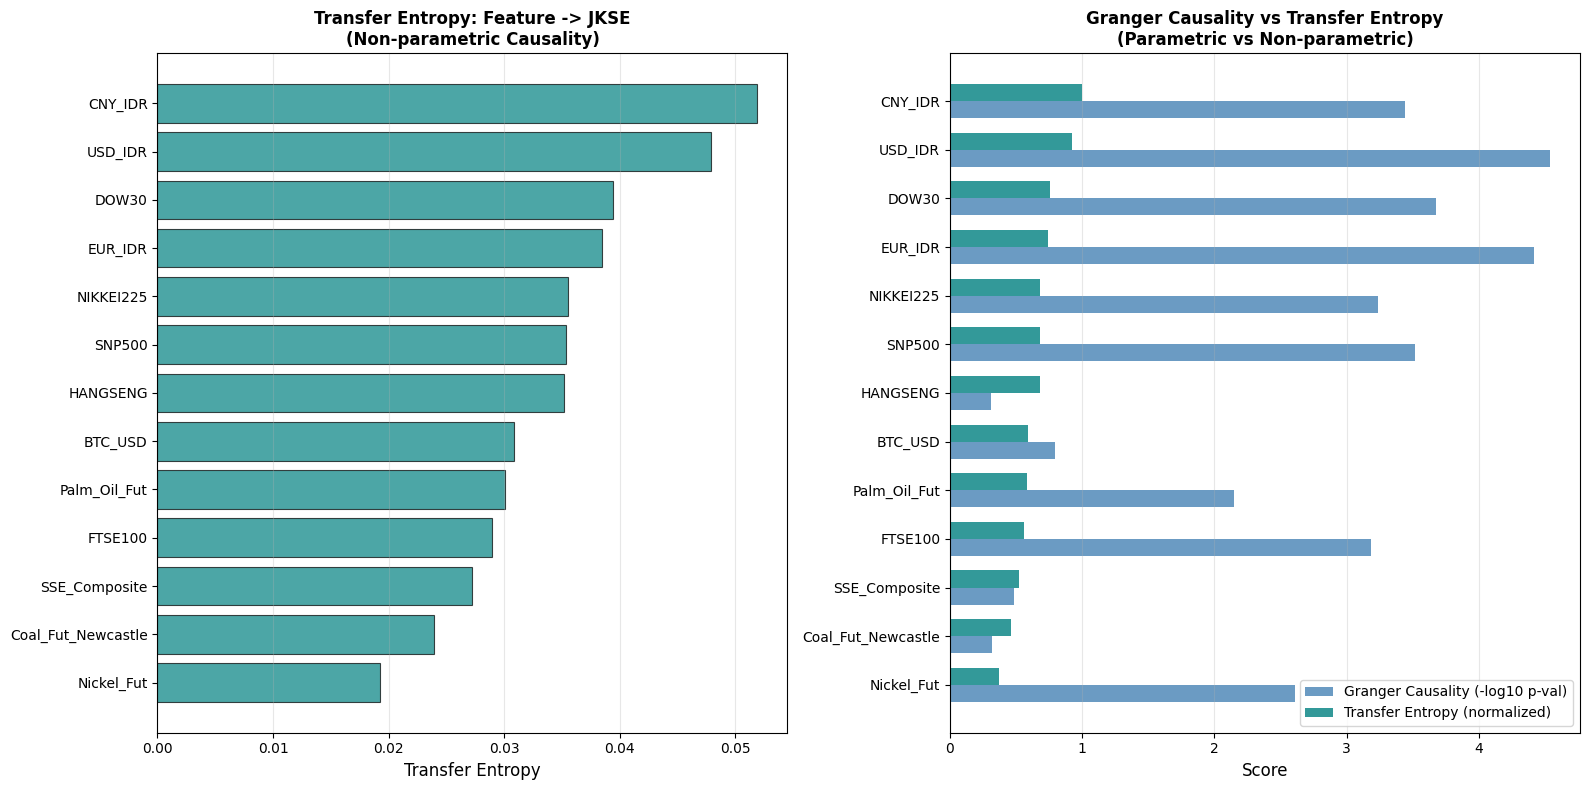

In [16]:
# VISUALIZATION 5: Transfer Entropy Analysis
print("\n" + "="*80)
print("VISUALIZATION 5: Transfer Entropy Analysis (Non-parametric Causality)")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# 1. Transfer Entropy Bar Plot
ax1 = axes[0]
te_plot_data = all_results.sort_values('TE_Score', ascending=True)
ax1.barh(te_plot_data['Feature'], te_plot_data['TE_Score'], color='teal', alpha=0.7, edgecolor='black', linewidth=0.8)
ax1.set_xlabel('Transfer Entropy', fontsize=12)
ax1.set_title('Transfer Entropy: Feature -> JKSE\n(Non-parametric Causality)', fontsize=12, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# 2. Comparison: Granger vs Transfer Entropy
ax2 = axes[1]
# Create sorted data for both methods
comparison_granger_te = all_results[['Feature', 'Granger_Pval', 'TE_Score']].copy()
comparison_granger_te['Granger_Sig'] = -np.log10(comparison_granger_te['Granger_Pval'].clip(lower=1e-10))
comparison_granger_te['TE_Norm'] = comparison_granger_te['TE_Score'] / comparison_granger_te['TE_Score'].max()
comparison_granger_te = comparison_granger_te.sort_values('TE_Norm', ascending=True)

x = np.arange(len(comparison_granger_te))
width = 0.35

ax2.barh(x - width/2, comparison_granger_te['Granger_Sig'], width, label='Granger Causality (-log10 p-val)', alpha=0.8, color='steelblue')
ax2.barh(x + width/2, comparison_granger_te['TE_Norm'], width, label='Transfer Entropy (normalized)', alpha=0.8, color='teal')
ax2.set_yticks(x)
ax2.set_yticklabels(comparison_granger_te['Feature'])
ax2.set_xlabel('Score', fontsize=12)
ax2.set_title('Granger Causality vs Transfer Entropy\n(Parametric vs Non-parametric)', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('Feature_Analysis_TransferEntropy.png', dpi=300, bbox_inches='tight')
print("\nVisualization 5 saved as 'Feature_Analysis_TransferEntropy.png'")
plt.show()



VISUALIZATION 2: Granger Causality & Method Comparison

Visualization 2 saved as 'Feature_Analysis_GrangerandComparison.png'


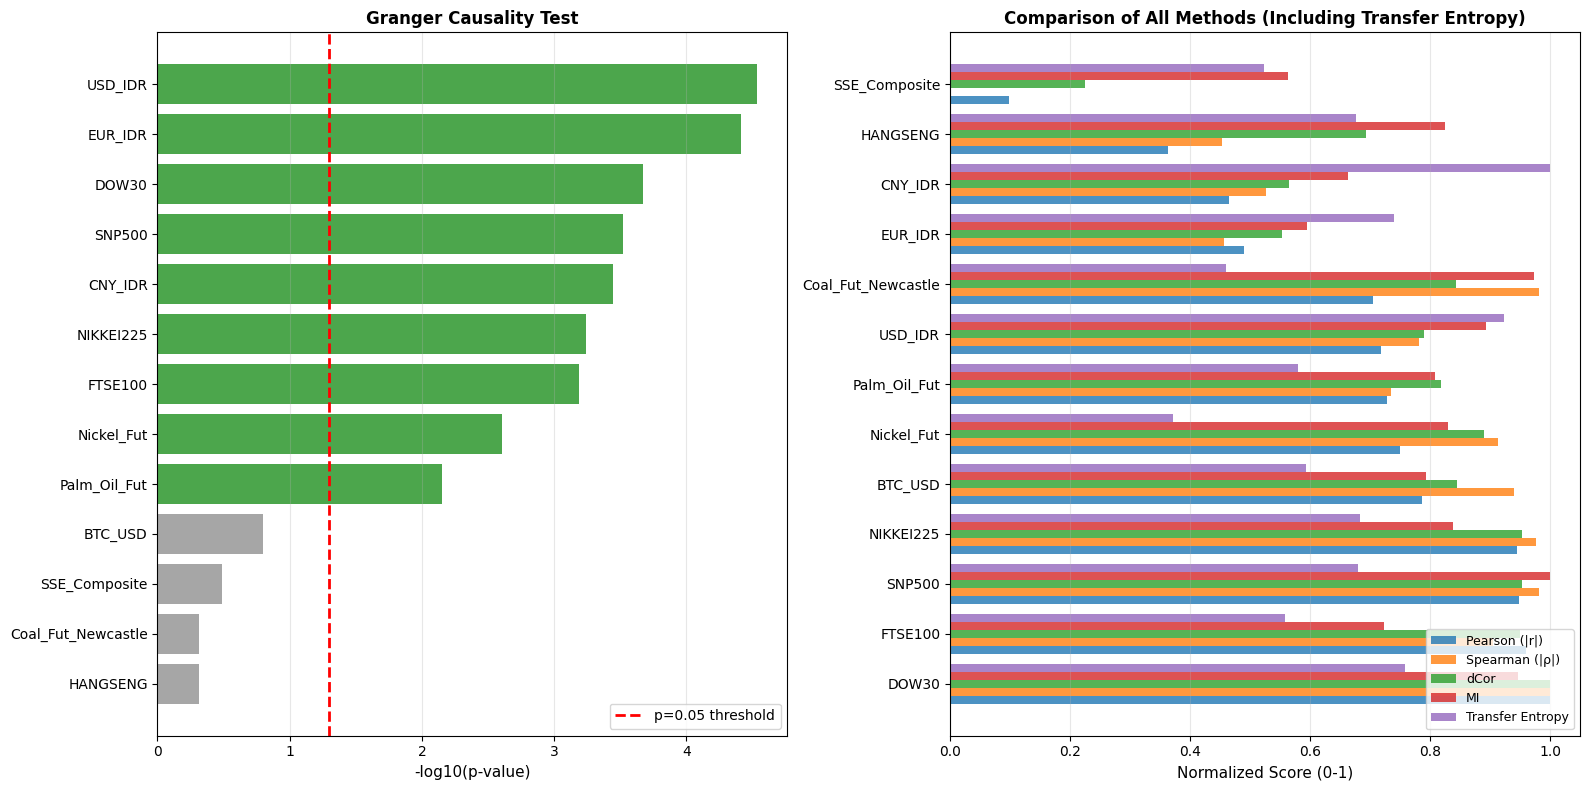

In [17]:
# VISUALIZATION 2: Granger Causality & Method Comparison
print("\n" + "="*80)
print("VISUALIZATION 2: Granger Causality & Method Comparison")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# 1. Granger Causality -log10(p-value) Plot
ax5 = axes[0]
granger_plot_data = all_results.copy()
granger_plot_data['neg_log_pval'] = -np.log10(granger_plot_data['Granger_Pval'].clip(lower=1e-10))
granger_plot_data = granger_plot_data.sort_values('neg_log_pval', ascending=True)
colors = ['green' if x > -np.log10(0.05) else 'gray' for x in granger_plot_data['neg_log_pval']]
ax5.barh(granger_plot_data['Feature'], granger_plot_data['neg_log_pval'], color=colors, alpha=0.7)
ax5.axvline(x=-np.log10(0.05), color='red', linestyle='--', linewidth=2, label='p=0.05 threshold')
ax5.set_xlabel('-log10(p-value)', fontsize=11)
ax5.set_title('Granger Causality Test', fontsize=12, fontweight='bold')
ax5.legend()
ax5.grid(axis='x', alpha=0.3)

# 2. Comparison of All Methods (normalized)
ax6 = axes[1]
comparison_data = all_results.copy()
# Normalize to 0-1 range for comparison
comparison_data['Pearson_Abs_Norm'] = comparison_data['Pearson_Corr'].abs() / comparison_data['Pearson_Corr'].abs().max()
comparison_data['Spearman_Abs_Norm'] = comparison_data['Spearman_Corr'].abs() / comparison_data['Spearman_Corr'].abs().max()
comparison_data['dCor_Norm'] = comparison_data['dCor'] / comparison_data['dCor'].max()
comparison_data['MI_Norm'] = comparison_data['MI_Score'] / comparison_data['MI_Score'].max()
comparison_data['TE_Norm'] = comparison_data['TE_Score'] / comparison_data['TE_Score'].max()

x = np.arange(len(comparison_data))
width = 0.16
ax6.barh(x - 2*width, comparison_data['Pearson_Abs_Norm'], width, label='Pearson (|r|)', alpha=0.8)
ax6.barh(x - width, comparison_data['Spearman_Abs_Norm'], width, label='Spearman (|ρ|)', alpha=0.8)
ax6.barh(x, comparison_data['dCor_Norm'], width, label='dCor', alpha=0.8)
ax6.barh(x + width, comparison_data['MI_Norm'], width, label='MI', alpha=0.8)
ax6.barh(x + 2*width, comparison_data['TE_Norm'], width, label='Transfer Entropy', alpha=0.8)
ax6.set_yticks(x)
ax6.set_yticklabels(comparison_data['Feature'])
ax6.set_xlabel('Normalized Score (0-1)', fontsize=11)
ax6.set_title('Comparison of All Methods (Including Transfer Entropy)', fontsize=12, fontweight='bold')
ax6.legend(loc='lower right', fontsize=9)
ax6.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('Feature_Analysis_GrangerandComparison.png', dpi=300, bbox_inches='tight')
print("\nVisualization 2 saved as 'Feature_Analysis_GrangerandComparison.png'")
plt.show()


ADDITIONAL VISUALIZATION: Full Correlation Matrix Heatmap

Full correlation matrix heatmap saved as 'Correlation_Matrix_Full.png'


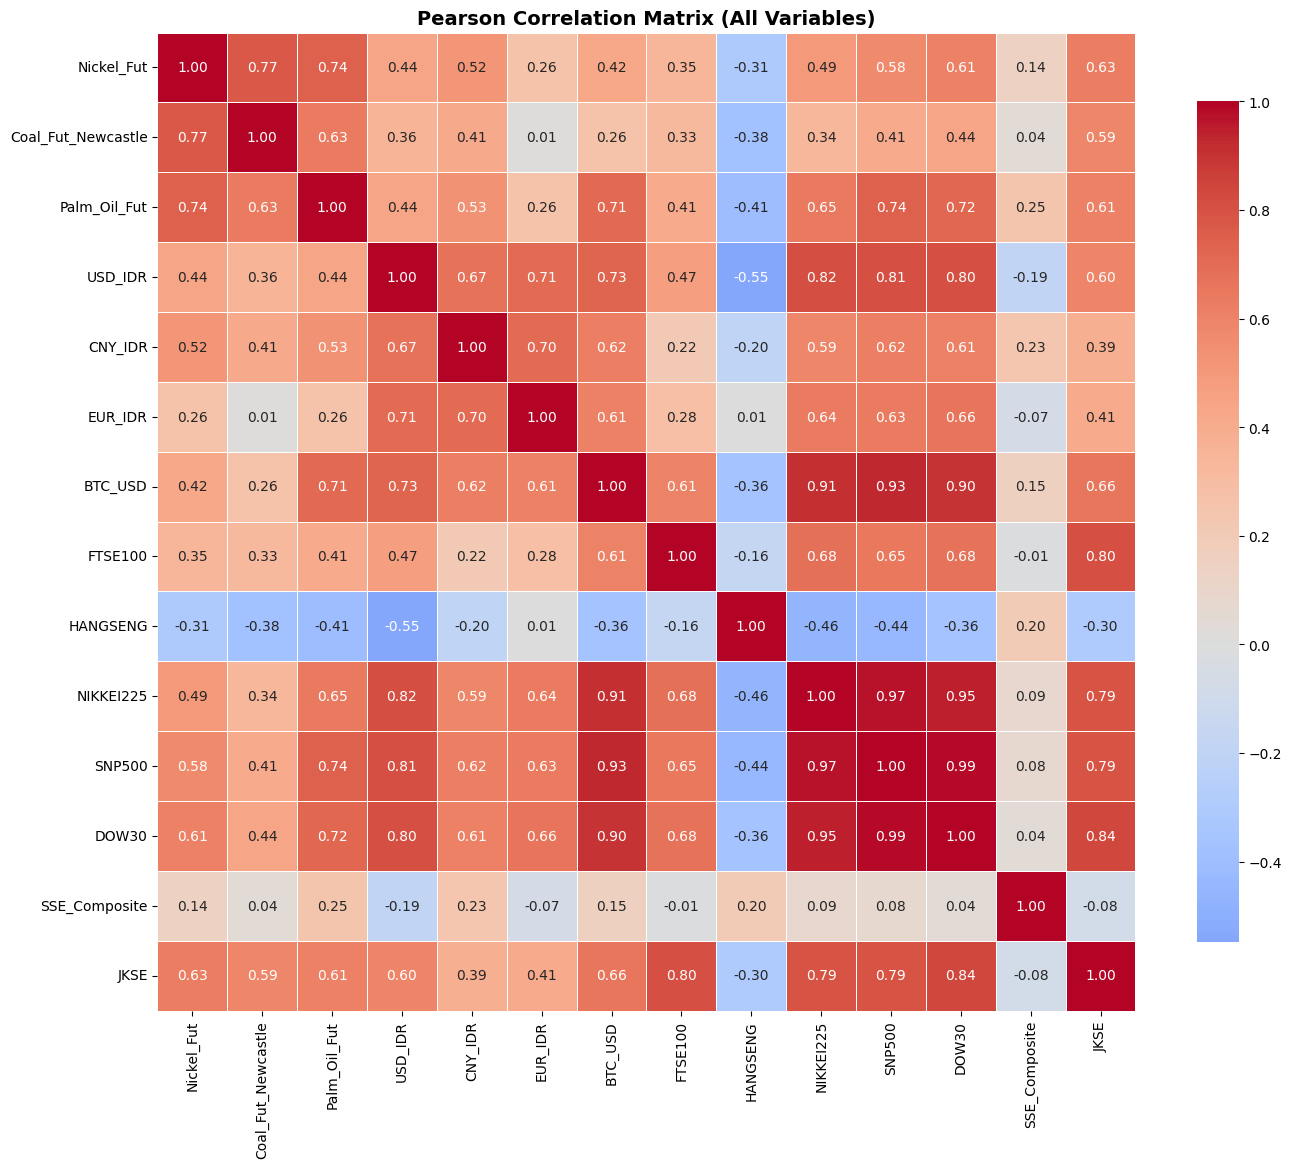

In [18]:
# ADDITIONAL VISUALIZATION: Full Correlation Matrix Heatmap
print("\n" + "="*80)
print("ADDITIONAL VISUALIZATION: Full Correlation Matrix Heatmap")
print("="*80)

# Calculate full correlation matrix (Pearson)
corr_matrix = df_clean.corr()

# Create figure with full correlation matrix heatmap
fig, ax = plt.subplots(figsize=(14, 12))

# Pearson Correlation Matrix Heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Pearson Correlation Matrix (All Variables)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('Correlation_Matrix_Full.png', dpi=300, bbox_inches='tight')
print("\nFull correlation matrix heatmap saved as 'Correlation_Matrix_Full.png'")
plt.show()


ADDITIONAL VISUALIZATION: Spearman Correlation Matrix Heatmap

Spearman correlation matrix heatmap saved as 'Correlation_Matrix_Spearman.png'


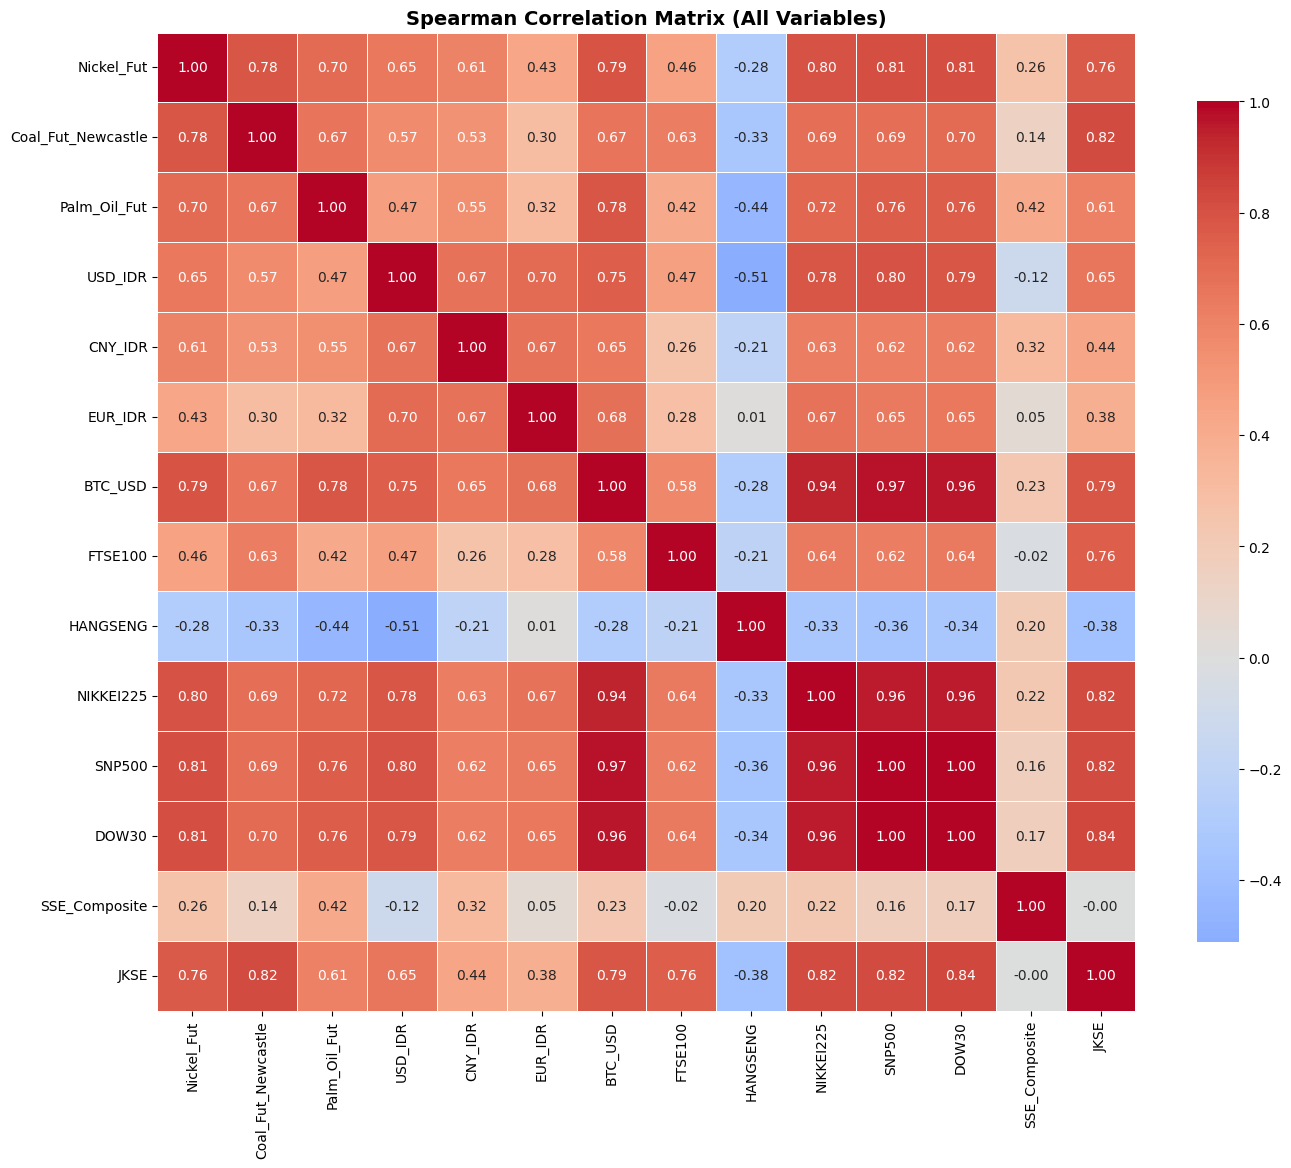

In [19]:
# ADDITIONAL VISUALIZATION: Spearman Correlation Matrix Heatmap
print("\n" + "="*80)
print("ADDITIONAL VISUALIZATION: Spearman Correlation Matrix Heatmap")
print("="*80)

# Calculate Spearman correlation matrix
spearman_corr_matrix = df_clean.corr(method='spearman')

# Create figure with Spearman correlation matrix heatmap
fig, ax = plt.subplots(figsize=(14, 12))

# Spearman Correlation Matrix Heatmap
sns.heatmap(spearman_corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Spearman Correlation Matrix (All Variables)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('Correlation_Matrix_Spearman.png', dpi=300, bbox_inches='tight')
print("\nSpearman correlation matrix heatmap saved as 'Correlation_Matrix_Spearman.png'")
plt.show()


ADDITIONAL VISUALIZATION: Granger Causality Matrix Heatmap (including JKSE)
Data reimported. Shape: (3654, 14)
Features: 13
Computing Granger causality matrix (this may take a while)...

Granger causality matrix heatmap saved as 'Granger_Causality_Matrix.png'


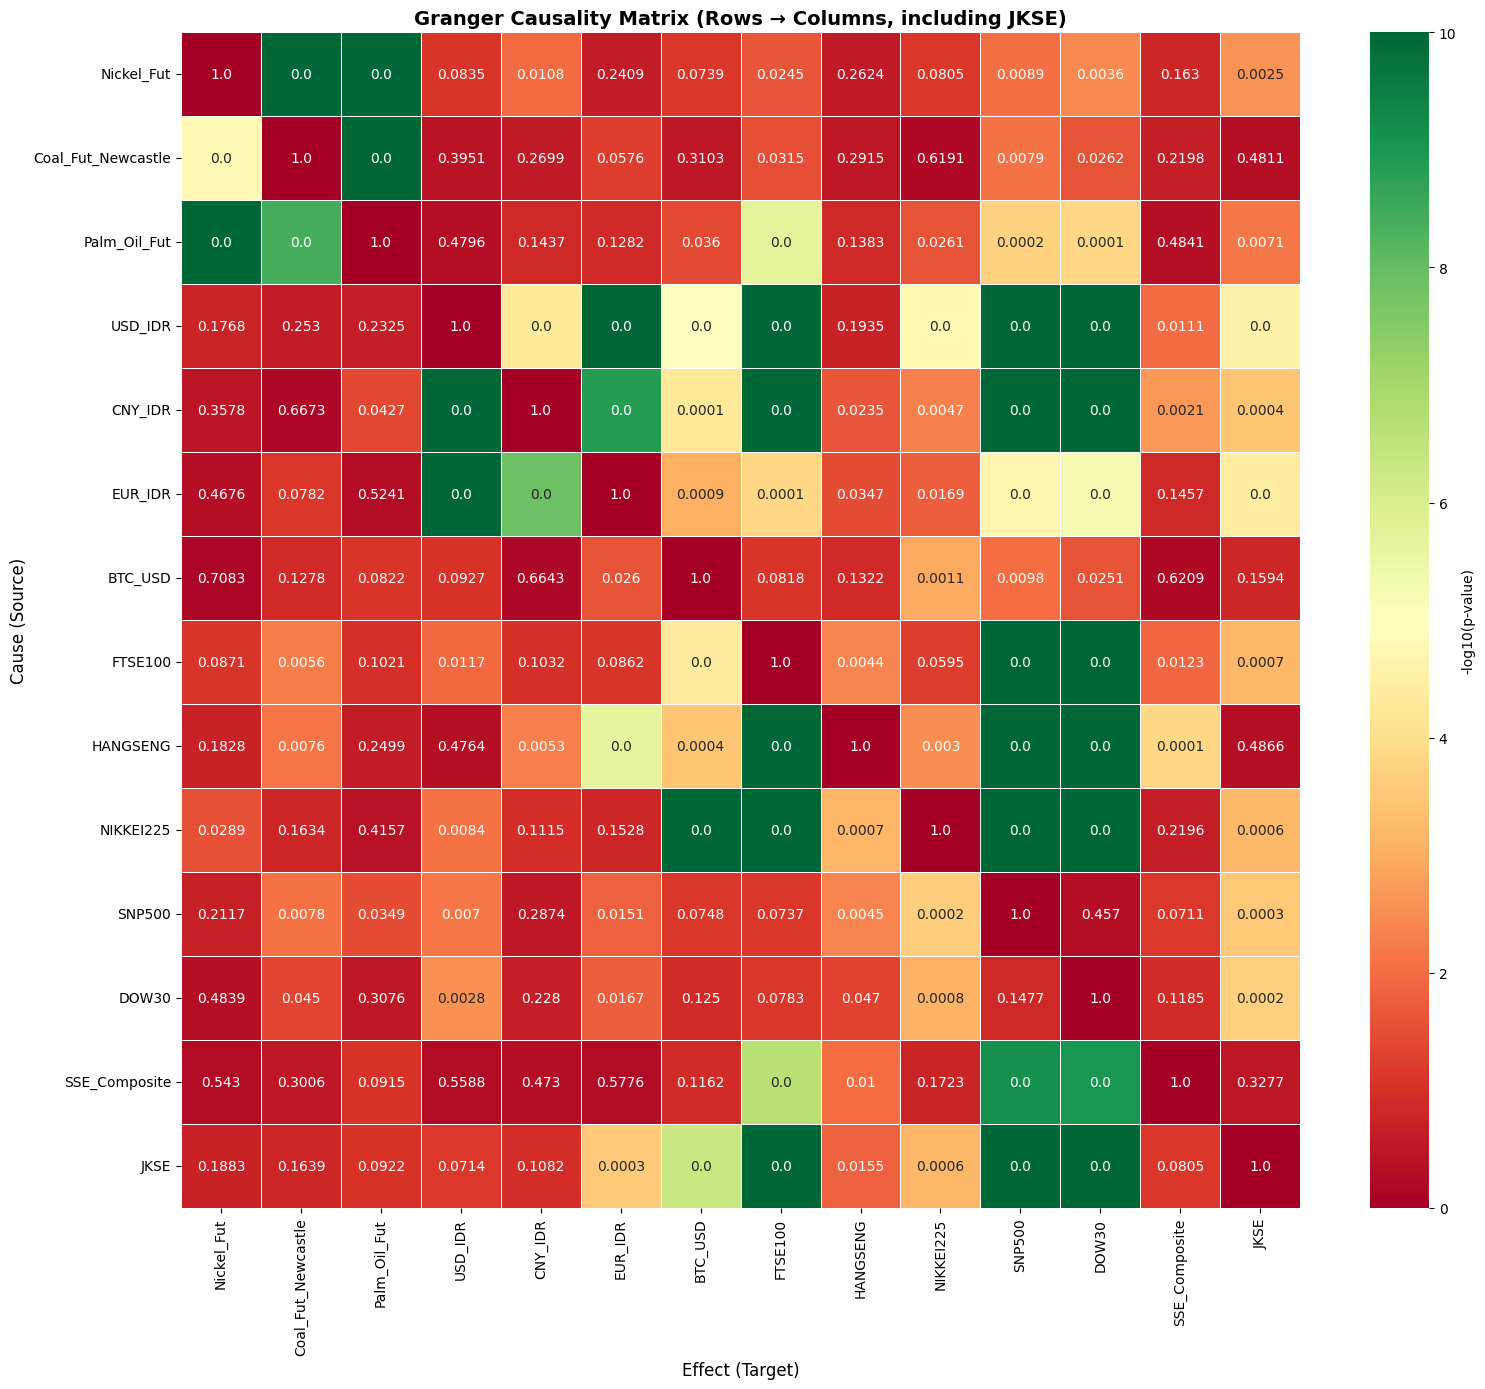


Granger Causality Matrix Summary:
(Values shown are p-values; lower values indicate stronger causality)
                      Nickel_Fut  Coal_Fut_Newcastle  Palm_Oil_Fut       USD_IDR       CNY_IDR       EUR_IDR       BTC_USD       FTSE100  HANGSENG  NIKKEI225         SNP500          DOW30  SSE_Composite      JKSE
Nickel_Fut          1.000000e+00        8.305048e-18  9.801571e-11  8.345145e-02  1.076277e-02  2.409069e-01  7.390405e-02  2.448836e-02  0.262382   0.080505   8.941923e-03   3.607343e-03       0.163031  0.002473
Coal_Fut_Newcastle  1.553560e-05        1.000000e+00  2.739978e-16  3.950671e-01  2.699321e-01  5.759867e-02  3.102827e-01  3.147489e-02  0.291544   0.619072   7.900177e-03   2.623172e-02       0.219833  0.481073
Palm_Oil_Fut        1.240210e-13        3.691280e-09  1.000000e+00  4.796033e-01  1.436780e-01  1.281620e-01  3.602261e-02  2.093448e-06  0.138307   0.026066   1.905331e-04   1.423680e-04       0.484068  0.007088
USD_IDR             1.768237e-01        2.5

In [25]:
# ADDITIONAL VISUALIZATION: Granger Causality Matrix Heatmap (including JKSE)
print("\n" + "="*80)
print("ADDITIONAL VISUALIZATION: Granger Causality Matrix Heatmap (including JKSE)")
print("="*80)

# Reimport the CSV to ensure data integrity
df_granger = pd.read_csv('ALL_MERGED.csv')
df_granger_clean = df_granger.drop('Date', axis=1)
granger_feature_cols = [col for col in df_granger_clean.columns if col != 'JKSE']
granger_target_col = 'JKSE'

print("Data reimported. Shape:", df_granger_clean.shape)
print("Features:", len(granger_feature_cols))

# Create Granger causality matrix - test causality between all variables including JKSE
# This will be an (n+1)x(n+1) matrix where rows are potential causes and columns are effects
max_lag = 5
all_vars = granger_feature_cols + [granger_target_col]  # Include JKSE
granger_matrix = np.zeros((len(all_vars), len(all_vars)))
granger_matrix[:] = np.nan

print("Computing Granger causality matrix (this may take a while)...\n")

for i, source in enumerate(all_vars):
    for j, target in enumerate(all_vars):
        if i == j:
            granger_matrix[i, j] = 1.0  # Self-causality is not defined, set to 1
        else:
            try:
                test_data = df_granger_clean[[source, target]].dropna()
                gc_result = grangercausalitytests(test_data, maxlag=max_lag, verbose=False)
                
                # Extract minimum p-value across lags
                p_values = [gc_result[lag][0]['ssr_ftest'][1] for lag in range(1, max_lag + 1)]
                min_pval = min(p_values)
                granger_matrix[i, j] = min_pval
                
            except Exception as e:
                granger_matrix[i, j] = np.nan

# Create dataframe for better visualization
granger_df_matrix = pd.DataFrame(granger_matrix, index=all_vars, columns=all_vars)

# Convert p-values to -log10 for better visualization
granger_df_matrix_log = -np.log10(granger_df_matrix.clip(lower=1e-10))

# Create figure
fig, ax = plt.subplots(figsize=(16, 14))

# Heatmap with p-values annotated
sns.heatmap(granger_df_matrix_log, annot=granger_df_matrix.round(4), fmt='', cmap='RdYlGn', 
            cbar_kws={"label": "-log10(p-value)"}, linewidths=0.5, ax=ax)
ax.set_title('Granger Causality Matrix (Rows → Columns, including JKSE)', fontsize=14, fontweight='bold')
ax.set_xlabel('Effect (Target)', fontsize=12)
ax.set_ylabel('Cause (Source)', fontsize=12)

plt.tight_layout()
plt.savefig('Granger_Causality_Matrix.png', dpi=300, bbox_inches='tight')
print("Granger causality matrix heatmap saved as 'Granger_Causality_Matrix.png'")
plt.show()

# Print summary
print("\nGranger Causality Matrix Summary:")
print("(Values shown are p-values; lower values indicate stronger causality)")
print(granger_df_matrix.to_string())


ADDITIONAL VISUALIZATION: Transfer Entropy Matrix Heatmap (including JKSE)
Data reimported. Shape: (3654, 14)
Features: 13
Computing Transfer Entropy matrix (this may take a while)...

Transfer Entropy matrix heatmap saved as 'Transfer_Entropy_Matrix.png'


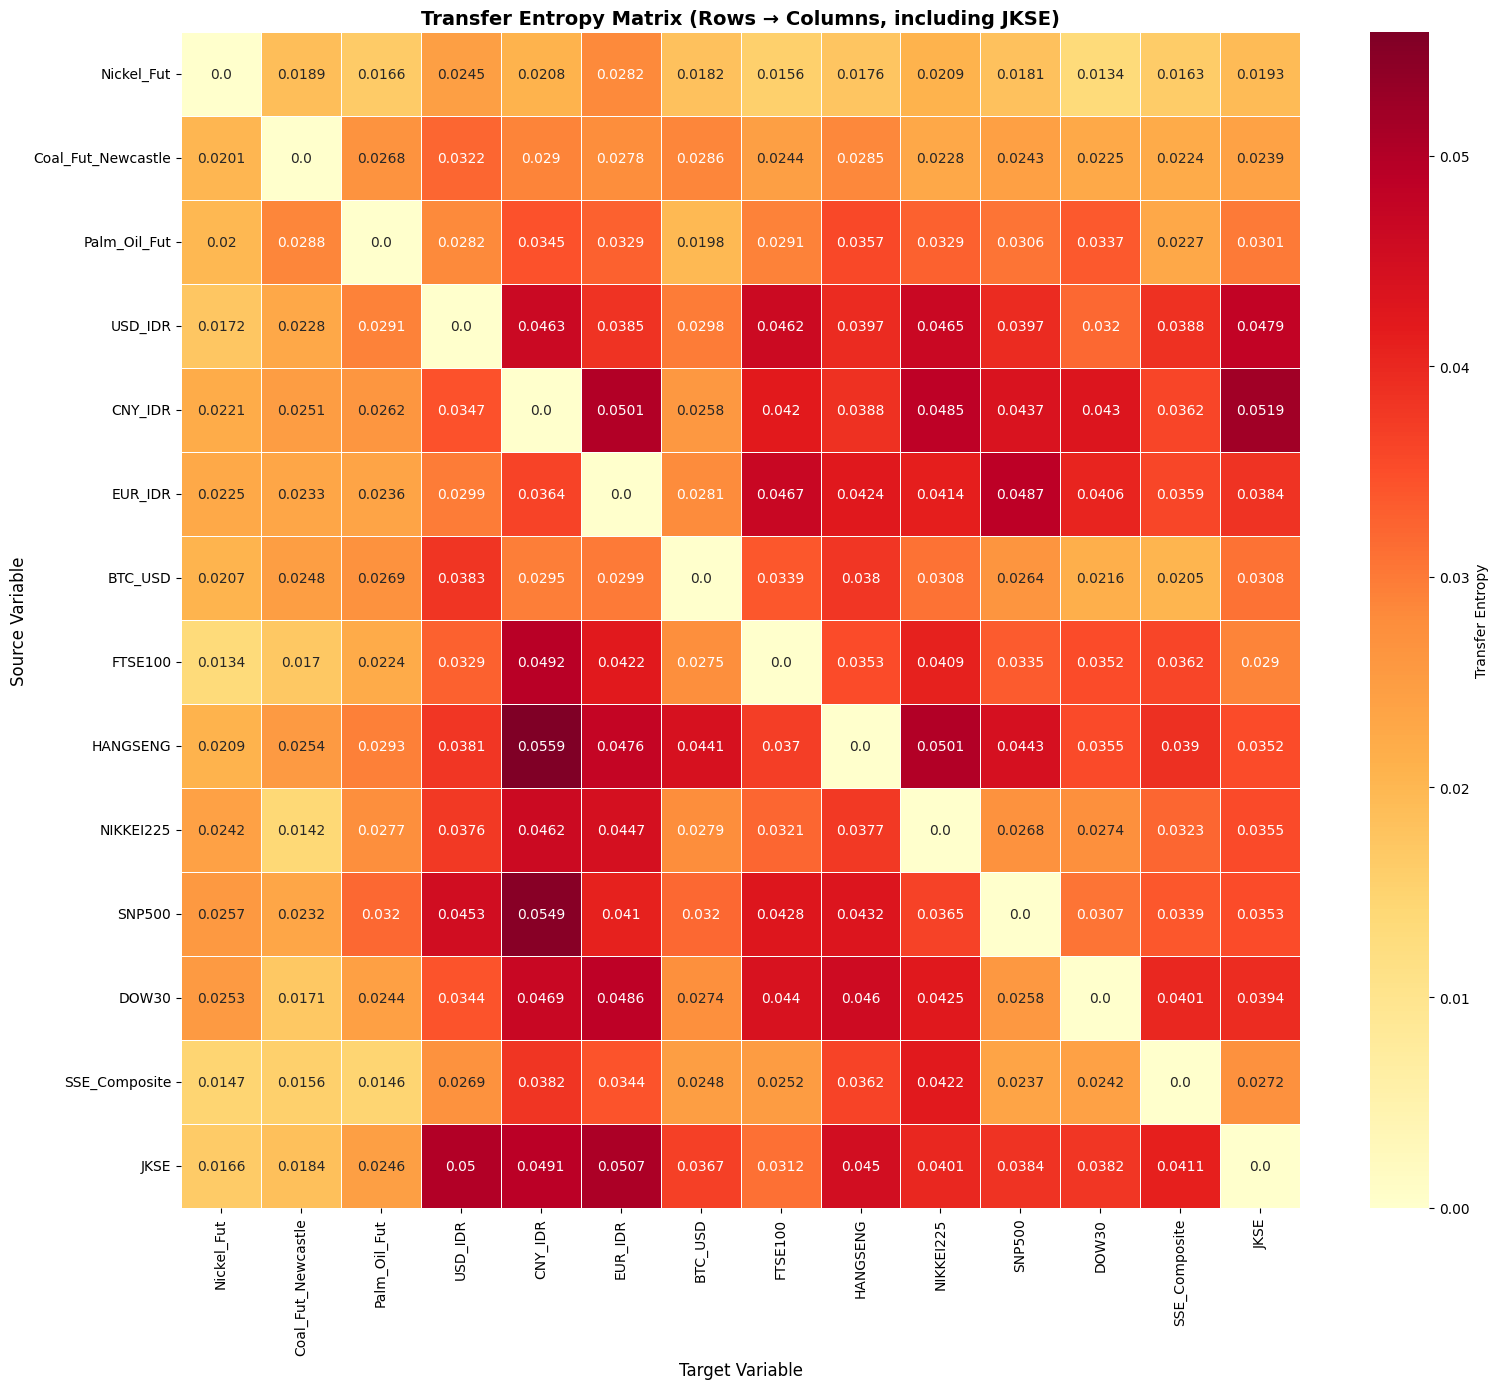


Transfer Entropy Matrix Summary:
(Values shown are Transfer Entropy scores; higher values indicate stronger information transfer)
                    Nickel_Fut  Coal_Fut_Newcastle  Palm_Oil_Fut  USD_IDR  CNY_IDR  EUR_IDR  BTC_USD  FTSE100  HANGSENG  NIKKEI225  SNP500   DOW30  SSE_Composite    JKSE
Nickel_Fut              0.0000              0.0189        0.0166   0.0245   0.0208   0.0282   0.0182   0.0156    0.0176     0.0209  0.0181  0.0134         0.0163  0.0193
Coal_Fut_Newcastle      0.0201              0.0000        0.0268   0.0322   0.0290   0.0278   0.0286   0.0244    0.0285     0.0228  0.0243  0.0225         0.0224  0.0239
Palm_Oil_Fut            0.0200              0.0288        0.0000   0.0282   0.0345   0.0329   0.0198   0.0291    0.0357     0.0329  0.0306  0.0337         0.0227  0.0301
USD_IDR                 0.0172              0.0228        0.0291   0.0000   0.0463   0.0385   0.0298   0.0462    0.0397     0.0465  0.0397  0.0320         0.0388  0.0479
CNY_IDR            

In [24]:
# ADDITIONAL VISUALIZATION: Transfer Entropy Matrix Heatmap (including JKSE)
print("\n" + "="*80)
print("ADDITIONAL VISUALIZATION: Transfer Entropy Matrix Heatmap (including JKSE)")
print("="*80)

# Reimport the CSV to ensure data integrity
df_te = pd.read_csv('ALL_MERGED.csv')
df_te_clean = df_te.drop('Date', axis=1)
te_feature_cols = [col for col in df_te_clean.columns if col != 'JKSE']
te_target_col = 'JKSE'

print("Data reimported. Shape:", df_te_clean.shape)
print("Features:", len(te_feature_cols))

# Create Transfer Entropy matrix - test TE from each variable to every other variable
# This will be an (n+1)x(n+1) matrix where rows are sources and columns are targets
all_te_vars = te_feature_cols + [te_target_col]  # Include JKSE
te_matrix = np.zeros((len(all_te_vars), len(all_te_vars)))
te_matrix[:] = np.nan

print("Computing Transfer Entropy matrix (this may take a while)...\n")

lag_value = 1
bins_value = 10

for i, source in enumerate(all_te_vars):
    for j, target in enumerate(all_te_vars):
        if i == j:
            te_matrix[i, j] = 0.0  # Self-TE is 0
        else:
            try:
                x = df_te_clean[source].values
                y = df_te_clean[target].values
                te_val = transfer_entropy(x, y, lag=lag_value, bins=bins_value)
                te_matrix[i, j] = te_val
                
            except Exception as e:
                te_matrix[i, j] = np.nan

# Create dataframe for better visualization
te_df_matrix = pd.DataFrame(te_matrix, index=all_te_vars, columns=all_te_vars)

# Create figure
fig, ax = plt.subplots(figsize=(16, 14))

# Heatmap with TE values annotated
sns.heatmap(te_df_matrix, annot=te_df_matrix.round(4), fmt='', cmap='YlOrRd', 
            cbar_kws={"label": "Transfer Entropy"}, linewidths=0.5, ax=ax)
ax.set_title('Transfer Entropy Matrix (Rows → Columns, including JKSE)', fontsize=14, fontweight='bold')
ax.set_xlabel('Target Variable', fontsize=12)
ax.set_ylabel('Source Variable', fontsize=12)

plt.tight_layout()
plt.savefig('Transfer_Entropy_Matrix.png', dpi=300, bbox_inches='tight')
print("Transfer Entropy matrix heatmap saved as 'Transfer_Entropy_Matrix.png'")
plt.show()

# Print summary
print("\nTransfer Entropy Matrix Summary:")
print("(Values shown are Transfer Entropy scores; higher values indicate stronger information transfer)")
print(te_df_matrix.round(4).to_string())


ADDITIONAL VISUALIZATION: Mutual Information Bar Chart (including JKSE)
Data reimported. Shape: (3654, 14)
Features: 13
Mutual Information bar chart saved as 'Feature_Analysis_MutualInformation.png'


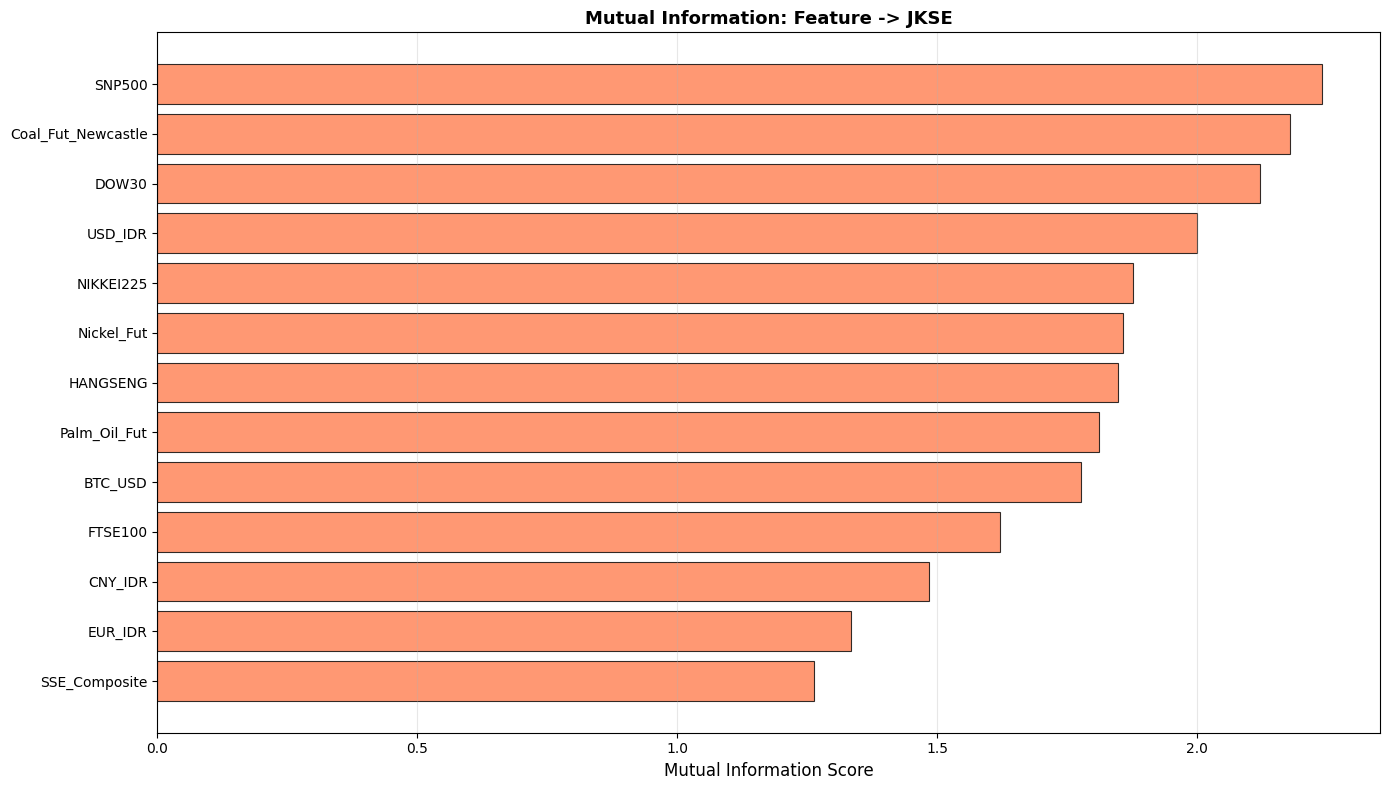


Mutual Information Scores:
           Feature  MI_Score
     SSE_Composite  1.263001
           EUR_IDR  1.333334
           CNY_IDR  1.484452
           FTSE100  1.621038
           BTC_USD  1.777153
      Palm_Oil_Fut  1.810717
          HANGSENG  1.847220
        Nickel_Fut  1.857577
         NIKKEI225  1.877045
           USD_IDR  1.999483
             DOW30  2.120650
Coal_Fut_Newcastle  2.178256
            SNP500  2.239805


In [27]:
# ADDITIONAL VISUALIZATION: Mutual Information Bar Chart (including JKSE)
print("\n" + "="*80)
print("ADDITIONAL VISUALIZATION: Mutual Information Bar Chart (including JKSE)")
print("="*80)

# Reimport the CSV to ensure data integrity
df_mi = pd.read_csv('ALL_MERGED.csv')
df_mi_clean = df_mi.drop('Date', axis=1)
mi_feature_cols = [col for col in df_mi_clean.columns if col != 'JKSE']
mi_target_col = 'JKSE'

print("Data reimported. Shape:", df_mi_clean.shape)
print("Features:", len(mi_feature_cols))

# Use the already calculated MI results or recalculate if needed
fig, ax = plt.subplots(figsize=(14, 8))

# Sort MI data by score
mi_plot_data = all_results.sort_values('MI_Score', ascending=True)

# Create horizontal bar chart
ax.barh(mi_plot_data['Feature'], mi_plot_data['MI_Score'], color='coral', alpha=0.8, edgecolor='black', linewidth=0.8)
ax.set_xlabel('Mutual Information Score', fontsize=12)
ax.set_title('Mutual Information: Feature -> JKSE', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('Feature_Analysis_MutualInformation.png', dpi=300, bbox_inches='tight')
print("Mutual Information bar chart saved as 'Feature_Analysis_MutualInformation.png'")
plt.show()

print("\nMutual Information Scores:")
print(mi_plot_data[['Feature', 'MI_Score']].to_string(index=False))